Dataset shape: (20631, 20)
Sensors remaining: ['setting_1', 'setting_2', 'setting_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


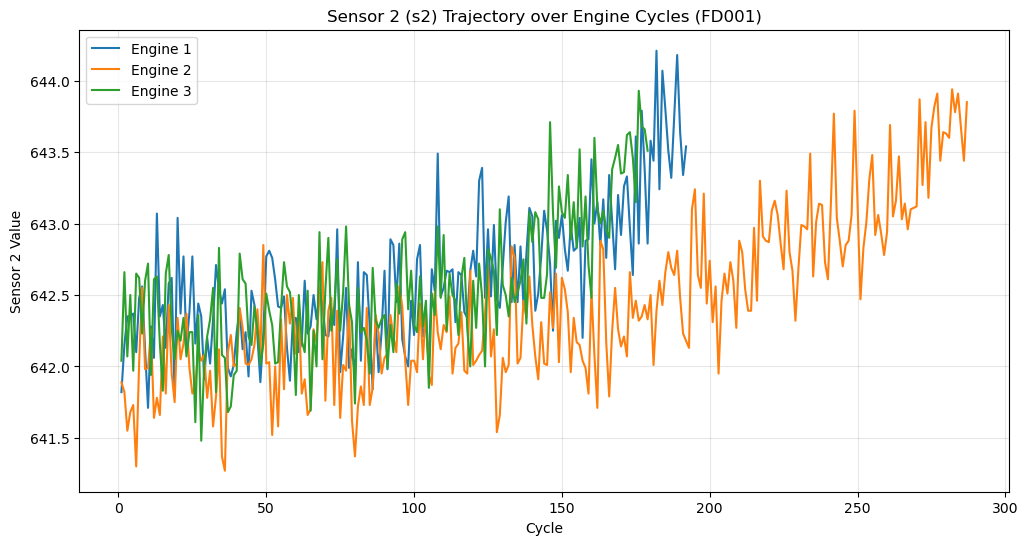

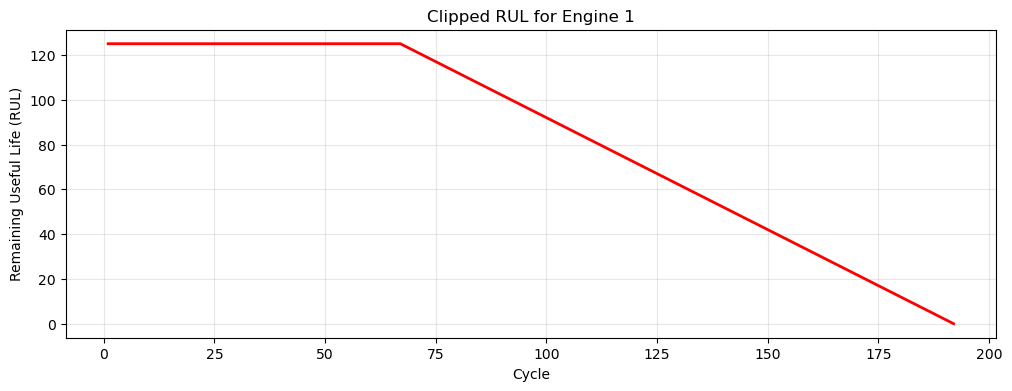

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define columns based on the C-MAPSS FD001 format
columns = ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]

# Load FD001 train data (space-separated)
train_df = pd.read_csv('../data/raw/turbofan/train_FD001.txt', sep='\s+', header=None, names=columns)

# 2. Drop the 7 constant sensors (near-zero variance in FD001)
drop_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
train_df.drop(columns=drop_sensors, inplace=True)

# 3. Compute RUL label (max_cycle - current_cycle)
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.rename(columns={'cycle': 'max_cycle'}, inplace=True)

train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# 4. Clip RUL at 125 (Standard practice for focusing on degradation signal)
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# Verify the shape and remaining sensors
print(f"Dataset shape: {train_df.shape}")
print(f"Sensors remaining: {[col for col in train_df.columns if col.startswith('s')]}")

# 5. Trajectory Plot: Visualizing degradation on a useful sensor (e.g., s2)
plt.figure(figsize=(12, 6))
for engine_id in [1, 2, 3]:  # Plotting the first 3 engines
    engine_data = train_df[train_df['engine_id'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['s2'], label=f'Engine {engine_id}')

plt.title('Sensor 2 (s2) Trajectory over Engine Cycles (FD001)')
plt.xlabel('Cycle')
plt.ylabel('Sensor 2 Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Verify RUL Clipping
plt.figure(figsize=(12, 4))
engine_1_data = train_df[train_df['engine_id'] == 1]
plt.plot(engine_1_data['cycle'], engine_1_data['RUL'], color='red', linewidth=2)
plt.title('Clipped RUL for Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (RUL)')
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
train_df.head()


,engine_id,cycle,setting_1,setting_2,setting_3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   s2         20631 non-null  float64
 6   s3         20631 non-null  float64
 7   s4         20631 non-null  float64
 8   s7         20631 non-null  float64
 9   s8         20631 non-null  float64
 10  s9         20631 non-null  float64
 11  s11        20631 non-null  float64
 12  s12        20631 non-null  float64
 13  s13        20631 non-null  float64
 14  s14        20631 non-null  float64
 15  s15        20631 non-null  float64
 16  s17        20631 non-null  int64  
 17  s20        20631 non-null  float64
 18  s21        20631 non-null  float64
 19  RUL        20631 non-null  int64  
dtypes: flo

<Axes: >

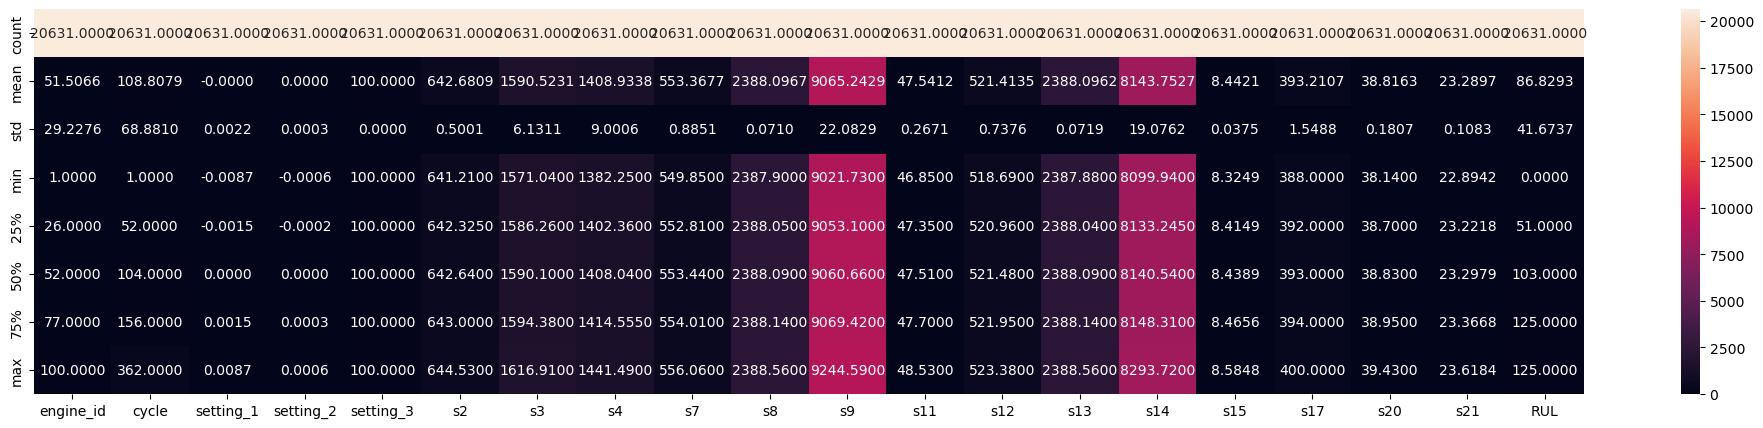

In [6]:
fig,ax = plt.subplots(figsize=(25,5))
sns.heatmap(train_df.describe(),ax =ax,annot=True,fmt='.4f')

In [9]:
train_df['RUL'].head()

0    125
1    125
2    125
3    125
4    125
Name: RUL, dtype: int64

### Sensor Correlation Heatmap

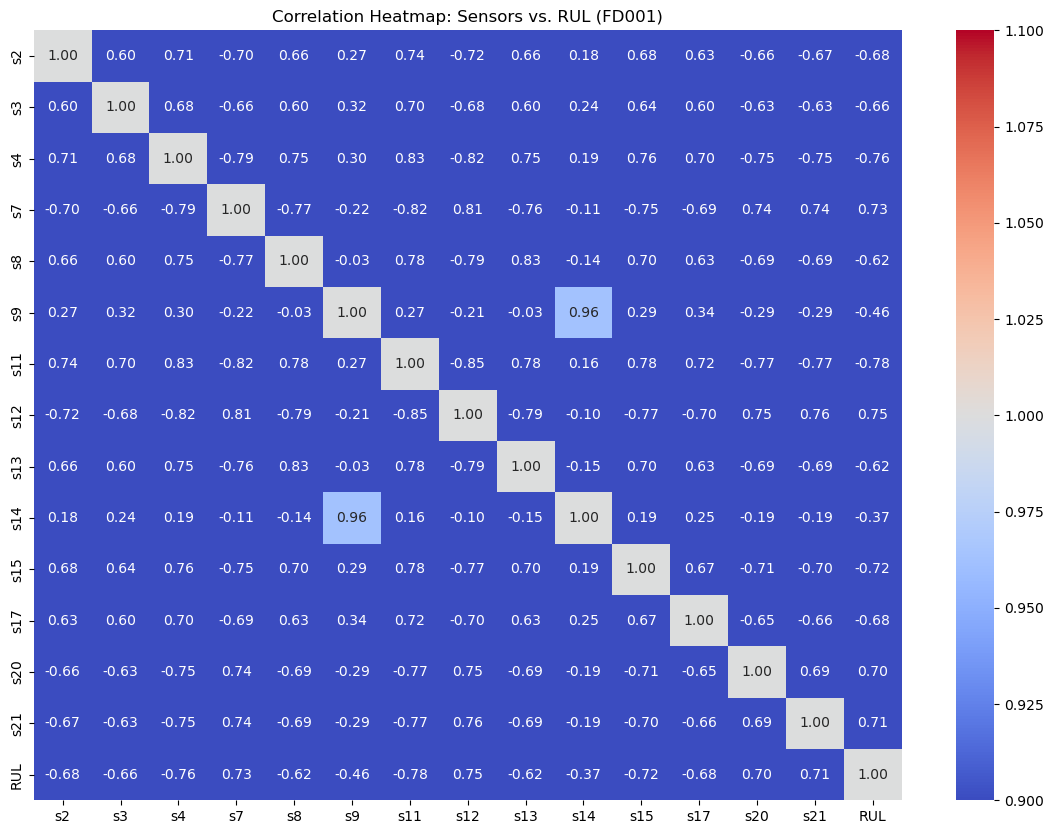

In [14]:
useful_sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
corr_cols = useful_sensors + ['RUL']
corr_matrix = train_df[corr_cols].astype(float).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=1.0, vmax=1.0)
plt.title('Correlation Heatmap: Sensors vs. RUL (FD001)')
plt.show()

### Healthy vs. Degraded State Distributions

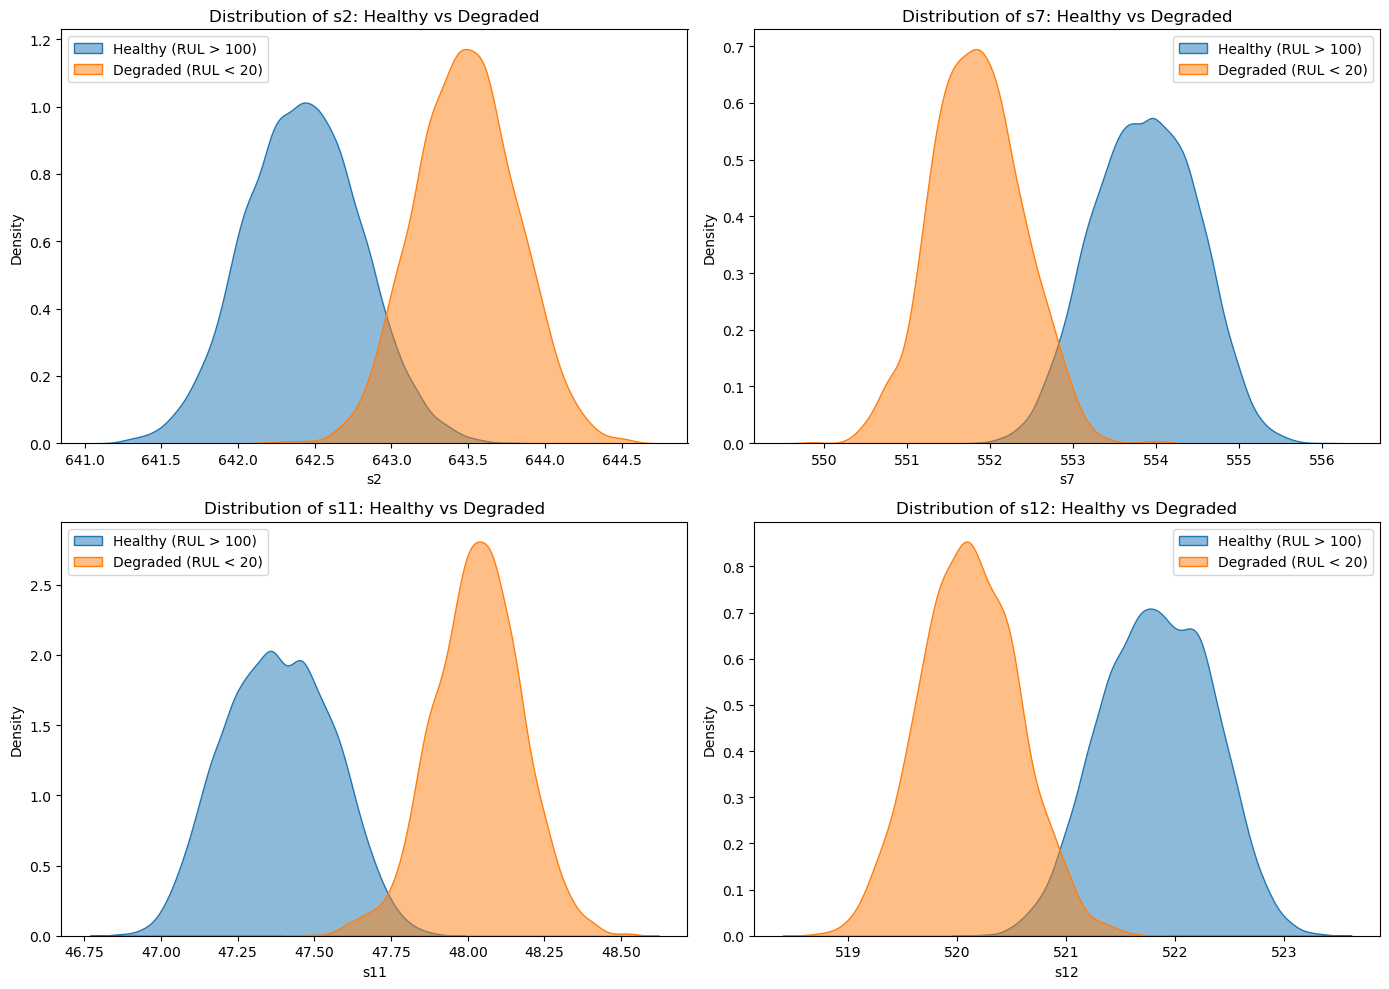

In [17]:
healthy_data = train_df[train_df['RUL'] > 100]
degraded_data = train_df[train_df['RUL'] < 20]

sensors_to_plot = ['s2', 's7', 's11', 's12']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    sns.kdeplot(healthy_data[sensor], label='Healthy (RUL > 100)', fill=True, ax=axes[i], alpha=0.5)
    sns.kdeplot(degraded_data[sensor], label='Degraded (RUL < 20)', fill=True, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Distribution of {sensor}: Healthy vs Degraded")
    axes[i].legend()

plt.tight_layout()
plt.show()

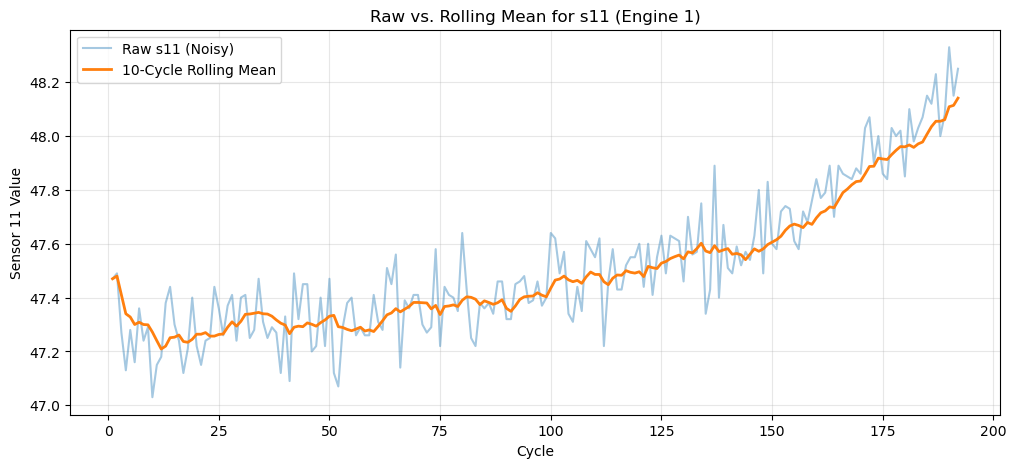

In [18]:
engine_1 = train_df[train_df['engine_id'] == 1].copy()

# Calculate a 10-cycle rolling mean
engine_1['s11_rolling_10'] = engine_1['s11'].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(engine_1['cycle'], engine_1['s11'], alpha=0.4, label='Raw s11 (Noisy)')
plt.plot(engine_1['cycle'], engine_1['s11_rolling_10'], linewidth=2, label='10-Cycle Rolling Mean')
plt.title('Raw vs. Rolling Mean for s11 (Engine 1)')
plt.xlabel('Cycle')
plt.ylabel('Sensor 11 Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()